# IMDb Sentiment Classification with LSTM — Practice Notebook

Train an `nn.LSTM` on the IMDb reviews dataset to classify movie review sentiment (positive/negative).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import Counter

import pandas as pd
import torch
from colorama import Fore, Style
from datasets import load_dataset
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

from dl_roadmap.engine import ClassPredictor, Trainer, TrainerConfig
from dl_roadmap.metrics.classification import evaluate_binary_classification
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_confusion_matrix, plot_training_history

In [3]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [4]:
dataset = load_dataset("stanfordnlp/imdb", cache_dir="../data/raw")

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["test"])

### Overview

In [5]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB

====== val ======
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 31.2 MB


In [6]:
print(f"{Fore.GREEN}DataFrame Description:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.describe(include="all"))

DataFrame Description:

====== train ======
                                                     text        label
count                                               25000  25000.00000
unique                                              24904          NaN
top     This show comes up with interesting locations ...          NaN
freq                                                    3          NaN
mean                                                  NaN      0.50000
std                                                   NaN      0.50001
min                                                   NaN      0.00000
25%                                                   NaN      0.00000
50%                                                   NaN      0.50000
75%                                                   NaN      1.00000
max                                                   NaN      1.00000

====== val ======
                                                     text        label
count         

In [7]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0

====== val ======
                                                text  label
0  I love sci-fi and am willing to put up with a ...      0
1  Worth the entertainment value of a rental, esp...      0
2  its a totally average film with a few semi-alr...      0
3  STAR RATING: ***** Saturday Night **** Friday ...      0
4  First off let me say, If you haven't enjoyed a...      0


In [8]:
print(f"{Fore.RED}Missing Values in Each Column:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
    print(missing_df)

Missing Values in Each Column:

====== train ======
       Missing Count  Missing %
text               0        0.0
label              0        0.0

====== val ======
       Missing Count  Missing %
text               0        0.0
label              0        0.0


### Preprocessing

In [9]:
def prepare(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercases review text and splits it into word tokens.

    Args:
        df: DataFrame with a raw ``text`` column.

    Returns:
        The same DataFrame with ``text`` replaced by a list of
        lowercase word/number tokens.
    """
    df["text"] = df["text"].str.lower()
    df["text"] = df["text"].str.findall(r"[a-z0-9']+")

    return df


train_df = prepare(train_df)
val_df = prepare(val_df)

In [10]:
train_df.head()

,text,label
0,"[i, rented, i, am, curious, yellow, from, my, ...",0
1,"[i, am, curious, yellow, is, a, risible, and, ...",0
2,"[if, only, to, avoid, making, this, type, of, ...",0
3,"[this, film, was, probably, inspired, by, goda...",0
4,"[oh, brother, after, hearing, about, this, rid...",0


### Tokenization

In [11]:
MAX_VOCAB_SIZE = 30_000

special_tokens = ["<PAD>", "<UNK>"]

word_counts = Counter()
for example in train_df["text"]:
    word_counts.update(example)

most_common_words = word_counts.most_common(MAX_VOCAB_SIZE - len(special_tokens))

tokens = special_tokens + [word for word, _ in most_common_words]

itos = {i: ch for i, ch in enumerate(tokens)}
stoi = {ch: i for i, ch in enumerate(tokens)}

vocab_size = len(itos)

In [12]:
class IMDbDataset(Dataset):
    """IMDb reviews dataset of tokenized text and sentiment labels."""

    def __init__(
        self, df: pd.DataFrame, stoi: dict[str, int], max_length: int = 256
    ) -> None:
        """Initializes the dataset.

        Args:
            df: DataFrame with tokenized ``text`` and ``label`` columns.
            stoi: Mapping from token to its id.
            max_length: Maximum sequence length.
        """
        super().__init__()

        self.df = df
        self.stoi = stoi
        self.max_length = max_length

        self._unk_id = stoi.get("<UNK>", -1)

    def __len__(self) -> int:
        """Returns the number of reviews in the dataset."""
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns the token id sequence and label for a review.

        Args:
            idx: Index of the review in the dataset.

        Returns:
            A tuple of the token id sequence and the sentiment label, both as
            long tensors.
        """
        row = self.df.iloc[idx]
        text, label = row["text"], row["label"]

        half = self.max_length // 2
        text = text[:half] + text[-half:]

        x_raw = list(text)

        x = torch.tensor(
            [self.stoi.get(ch, self._unk_id) for ch in x_raw],
            dtype=torch.long,
        )
        y = torch.tensor(label, dtype=torch.long)

        return x, y

### Collation

In [13]:
pad_id = stoi["<PAD>"]


def collate_fn(
    batch: list[tuple[torch.Tensor, torch.Tensor]],
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pads a batch of token id sequences to the same length.

    Args:
        batch: A list of (token ids, label) pairs of variable length.

    Returns:
        A tuple of the padded token id tensor (padded with ``pad_id`` and
        shaped ``batch_size x max_seq_len``) and the stacked label tensor.
    """
    xs, ys = zip(*batch)

    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = torch.tensor(ys)

    return xs, ys

In [14]:
train_dataset = IMDbDataset(train_df, stoi)
val_dataset = IMDbDataset(val_df, stoi)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
)

## Training

In [ ]:
class ImdbLSTM(nn.Module):
    """LSTM-based binary sentiment classifier for IMDb reviews."""

    def __init__(  # noqa: PLR0913
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_size: int = 128,
        num_layers: int = 1,
        dropout: float = 0.0,
        pad_id: int = 0,
    ) -> None:
        """Initializes the model.

        Args:
            vocab_size: Number of distinct tokens in the vocabulary.
            embedding_dim: Dimensionality of the token embeddings.
            hidden_size: Number of features in the LSTM hidden state.
            num_layers: Number of stacked LSTM layers.
            dropout: Dropout probability applied between stacked LSTM
                layers (ignored if ``num_layers == 1``) and to the final
                hidden state before the output layer.
            pad_id: Id of the ``<PAD>`` token, used to zero its embedding
                and to derive real sequence lengths in `forward`.
        """
        super().__init__()

        self.pad_id = pad_id

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id,
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(hidden_size * 2)

        self.drop = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size * 2, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Runs the forward pass.

        Args:
            x: Token id sequences, padded with ``pad_id``, shaped
                ``batch_size x seq_len``.

        Returns:
            Class logits of shape ``batch_size x 2``.
        """
        lengths = (x != self.pad_id).sum(dim=1).cpu()

        emb = self.embedding(x)
        packed = pack_padded_sequence(
            emb,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        _out, (hid, _c_n) = self.lstm(packed)

        forward_hid = hid[-2]
        backward_hid = hid[-1]

        combined_hid = torch.cat(
            (forward_hid, backward_hid),
            dim=1,
        )

        features = self.norm(combined_hid)
        features = self.dropout(features)

        logits = self.fc(features)
        return logits

In [ ]:
model = ImdbLSTM(vocab_size, num_layers=2, dropout=0.4)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=1
)
loss_fn = nn.CrossEntropyLoss()

trainer_config = TrainerConfig(epochs=15, patience=3, min_delta=1e-3)
trainer = Trainer(model, opt, loss_fn, scheduler, config=trainer_config)
history = trainer.fit(train_loader, val_loader)

Epoch  9/15:  60%[============        ] 3519/5865 :: eta=02:47, status=early stopped, train_loss=0.08185, val_loss=0.3541


## Results

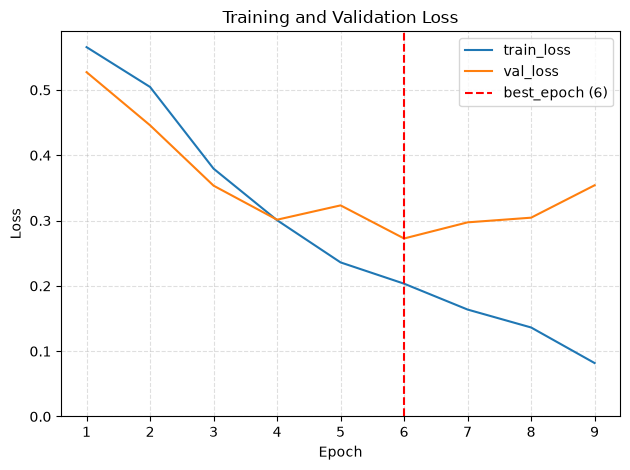

In [17]:
plot_training_history(**history, best_epoch=trainer.best_epoch)

In [18]:
X_val = torch.cat([xb for xb, *_ in val_loader])
y_val = torch.cat([yb for *_, yb in val_loader])

predictor = ClassPredictor(model)
y_pred = predictor.predict(X_val)

In [19]:
metrics = evaluate_binary_classification(y_pred, y_val)
pd.DataFrame(data=metrics, index=["model"])

,Accuracy,Precision,Recall,F1
model,0.88548,0.893572,0.8752,0.88429


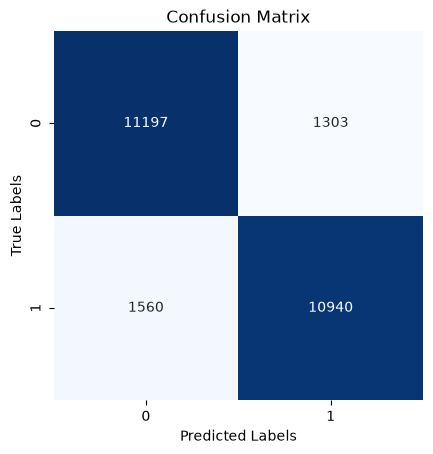

In [20]:
plot_confusion_matrix(y_pred, y_val)